# Transfer Learning USAD → SIATA
**Objetivo:** Transferir el conocimiento del modelo USAD (entrenado con 51 sensores del dataset SWaT) a 4 canales de temperatura de la red SIATA (Medellín) para detectar datos anómalos.

**Estaciones:**
- Sensor 68 — Jardín Botánico
- Sensor 201 — Torre SIATA
- Sensor 203 — UNAL
- Sensor 478 — Fiscalía

**Estrategia de sub-matriz:** Se extrae un bloque de pesos del encoder pre-entrenado que corresponde a los primeros `w_size_new` pesos, inicializando el nuevo modelo con ese conocimiento.

In [1]:
# ── 1. Dependencias ────────────────────────────────────────────────────────────
!pip install torch scikit-learn pandas matplotlib seaborn -q

In [2]:
# ── 2. Clonar repositorio ──────────────────────────────────────────────────────
import os

REPO_URL    = "https://github.com/ronvas234/data-science-monograph.git"
REPO_BRANCH = "feature/transfer-learning-plan-e"   # rama con los datos
REPO_DIR    = "data-science-monograph"

if not os.path.exists(REPO_DIR):
    !git clone --branch {REPO_BRANCH} {REPO_URL} {REPO_DIR}
else:
    !git -C {REPO_DIR} pull

BASE   = f"{REPO_DIR}/modelos/usad"
DATA   = f"{BASE}/data/plan_a"
print("Repo listo en:", BASE)

Cloning into 'data-science-monograph'...
remote: Enumerating objects: 261, done.
remote: Counting objects: 100% (108/108), done.
remote: Compressing objects: 100% (79/79), done.
remote: Total 261 (delta 22), reused 81 (delta 13), pack-reused 153 (from 1)
Receiving objects: 100% (261/261), 19.60 MiB | 17.97 MiB/s, done.
Resolving deltas: 100% (68/68), done.
Repo listo en: data-science-monograph/modelos/usad


In [3]:
# ── 3. Imports ─────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (roc_curve, roc_auc_score,
                              f1_score, accuracy_score,
                              precision_score, recall_score,
                              confusion_matrix as sk_confusion_matrix)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

In [4]:
# ── 4. Configuración global ────────────────────────────────────────────────────
SENSOR_IDS   = [68, 201, 203, 478]
WINDOW_SIZE  = 12          # misma ventana que el modelo original
N_SENSORS    = 4
W_SIZE_NEW   = WINDOW_SIZE * N_SENSORS    # 48
Z_SIZE_NEW   = W_SIZE_NEW                 # 48  (latente proporcional)

# Pesos originales (modelo SWaT)
W_SIZE_ORIG  = 51 * WINDOW_SIZE           # 612
Z_SIZE_ORIG  = 1200

BATCH_SIZE   = 256
EPOCHS_P1    = 10    # fase 1: encoder congelado
EPOCHS_P2    = 40    # fase 2: fine-tune completo
LR           = 1e-3
ALPHA        = 0.5   # peso decoder1 en score de anomalía
BETA         = 0.5   # peso decoder2 en score de anomalía

# Splits derivados por fecha (sin usar columna Split del CSV)
SPLIT_DATES = {
    "train": ("2023-03-29", "2023-04-23"),
    "val":   ("2023-04-24", "2023-04-28"),
    "test":  ("2023-06-09", "2023-07-05"),
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE} | w_size_new={W_SIZE_NEW} | z_size_new={Z_SIZE_NEW}")

Dispositivo: cpu | w_size_new=48 | z_size_new=48


## Clase 1 — `SIATADataLoader`
**Responsabilidad única:** cargar y preparar los datos de los 4 sensores SIATA.

In [5]:
class SIATADataLoader:
    """Carga, limpia, normaliza y ventana los 4 sensores SIATA.

    Elimina la columna Split del CSV y deriva los conjuntos por rango de fechas.
    La columna `flag` (0=normal, 1=anomalía) se conserva como ground truth.
    """

    def __init__(self, data_dir: str, sensor_ids: list,
                 split_dates: dict, window_size: int, batch_size: int):
        self.data_dir    = data_dir
        self.sensor_ids  = sensor_ids
        self.split_dates = split_dates
        self.window_size = window_size
        self.batch_size  = batch_size
        self.scaler      = MinMaxScaler()
        self._df         = None      # DataFrame multi-sensor alineado

    # ── Paso 1: cargar y unir los 4 CSV ────────────────────────────────────────
    def _load_raw(self) -> pd.DataFrame:
        frames = []
        for sid in self.sensor_ids:
            path = f"{self.data_dir}/{sid}.csv"
            df   = pd.read_csv(path, parse_dates=["fecha_hora"])
            df.drop(columns=[c for c in df.columns
                              if c.lower() == "split"], inplace=True)
            df.rename(columns={"t": f"t_{sid}",
                                "flag": f"flag_{sid}"}, inplace=True)
            frames.append(df.set_index("fecha_hora"))

        combined = frames[0]
        for f in frames[1:]:
            combined = combined.join(f, how="inner")
        combined.dropna(inplace=True)
        combined.sort_index(inplace=True)
        return combined

    # ── Paso 2: dividir por rango de fechas ────────────────────────────────────
    def _split(self, df: pd.DataFrame):
        splits = {}
        for name, (start, end) in self.split_dates.items():
            mask = (df.index >= start) & (df.index <= end)
            splits[name] = df[mask].copy()
        return splits

    # ── Paso 3: normalizar (fit solo en train) ─────────────────────────────────
    def _normalize(self, splits: dict):
        feat_cols = [f"t_{s}" for s in self.sensor_ids]
        self.scaler.fit(splits["train"][feat_cols])
        normalized = {}
        for name, df in splits.items():
            d = df.copy()
            d[feat_cols] = self.scaler.transform(d[feat_cols])
            normalized[name] = d
        return normalized

    # ── Paso 4: crear ventanas deslizantes ─────────────────────────────────────
    def _make_windows(self, df: pd.DataFrame):
        feat_cols = [f"t_{s}" for s in self.sensor_ids]
        flag_cols = [f"flag_{s}" for s in self.sensor_ids]
        vals  = df[feat_cols].values   # (T, 4)
        flags = df[flag_cols].values   # (T, 4)
        ts    = df.index               # timestamps

        n = len(vals) - self.window_size
        idx     = np.arange(self.window_size)[None, :] + np.arange(n)[:, None]
        windows = vals[idx].reshape(n, -1).astype(np.float32)  # (n, 48)

        # etiqueta: 1 si algún punto de la ventana en algún sensor es anómalo
        labels  = flags[idx].any(axis=(1, 2)).astype(int)      # (n,)
        # timestamp del último punto de cada ventana
        timestamps = ts[self.window_size:]
        return windows, labels, timestamps

    # ── Paso 5: construir DataLoaders ──────────────────────────────────────────
    def build(self):
        raw    = self._load_raw()
        splits = self._split(raw)
        splits = self._normalize(splits)

        self.windows = {}
        self.labels  = {}
        self.timestamps = {}
        loaders = {}

        for name, df in splits.items():
            w, lbl, ts = self._make_windows(df)
            self.windows[name]    = w
            self.labels[name]     = lbl
            self.timestamps[name] = ts
            tensor   = torch.tensor(w)
            dataset  = TensorDataset(tensor)
            shuffle  = (name == "train")
            loaders[name] = DataLoader(dataset,
                                       batch_size=self.batch_size,
                                       shuffle=shuffle)
            print(f"  [{name}] ventanas={len(w):,}  "
                  f"anomalías={lbl.sum():,} ({lbl.mean()*100:.2f}%)")

        self.train_loader = loaders["train"]
        self.val_loader   = loaders["val"]
        self.test_loader  = loaders["test"]
        return self

## Arquitectura USAD (inline — sin depender del archivo local)

In [6]:
class Encoder(nn.Module):
    def __init__(self, in_size, latent_size):
        super().__init__()
        self.linear1 = nn.Linear(in_size, in_size // 2)
        self.linear2 = nn.Linear(in_size // 2, in_size // 4)
        self.linear3 = nn.Linear(in_size // 4, latent_size)
        self.relu    = nn.ReLU(True)

    def forward(self, w):
        out = self.relu(self.linear1(w))
        out = self.relu(self.linear2(out))
        return self.relu(self.linear3(out))


class Decoder(nn.Module):
    def __init__(self, latent_size, out_size):
        super().__init__()
        self.linear1 = nn.Linear(latent_size, out_size // 4)
        self.linear2 = nn.Linear(out_size // 4, out_size // 2)
        self.linear3 = nn.Linear(out_size // 2, out_size)
        self.relu    = nn.ReLU(True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, z):
        out = self.relu(self.linear1(z))
        out = self.relu(self.linear2(out))
        return self.sigmoid(self.linear3(out))


class UsadModel(nn.Module):
    def __init__(self, w_size, z_size):
        super().__init__()
        self.encoder  = Encoder(w_size, z_size)
        self.decoder1 = Decoder(z_size, w_size)
        self.decoder2 = Decoder(z_size, w_size)

    def training_step(self, batch, n):
        z  = self.encoder(batch)
        w1 = self.decoder1(z)
        w2 = self.decoder2(z)
        w3 = self.decoder2(self.encoder(w1))
        loss1 = (1/n) * torch.mean((batch-w1)**2) + (1-1/n) * torch.mean((batch-w3)**2)
        loss2 = (1/n) * torch.mean((batch-w2)**2) - (1-1/n) * torch.mean((batch-w3)**2)
        return loss1, loss2

    def validation_step(self, batch, n):
        with torch.no_grad():
            z  = self.encoder(batch)
            w1 = self.decoder1(z)
            w2 = self.decoder2(z)
            w3 = self.decoder2(self.encoder(w1))
            loss1 = (1/n) * torch.mean((batch-w1)**2) + (1-1/n) * torch.mean((batch-w3)**2)
            loss2 = (1/n) * torch.mean((batch-w2)**2) - (1-1/n) * torch.mean((batch-w3)**2)
        return {"val_loss1": loss1, "val_loss2": loss2}

    def anomaly_scores(self, loader, alpha=0.5, beta=0.5, device="cpu"):
        scores = []
        self.eval()
        with torch.no_grad():
            for [batch] in loader:
                batch = batch.to(device)
                w1 = self.decoder1(self.encoder(batch))
                w2 = self.decoder2(self.encoder(w1))
                s  = alpha * torch.mean((batch-w1)**2, dim=1) \
                   + beta  * torch.mean((batch-w2)**2, dim=1)
                scores.append(s.cpu())
        return torch.cat(scores).numpy()

## Clase 2 — `TransferUSAD`
**Responsabilidad:** construir el modelo adaptado e inicializarlo con la sub-matriz del checkpoint pre-entrenado.

In [7]:
class TransferUSAD:
    """Construye y configura el modelo USAD para transfer learning con sub-matriz.

    Extrae bloques de los pesos originales (SWaT, 51 sensores) y los usa
    para inicializar el nuevo modelo (SIATA, 4 sensores).
    """

    def __init__(self, pretrained_path: str,
                 w_size_new: int, z_size_new: int, device):
        self.pretrained_path = pretrained_path
        self.w_size_new      = w_size_new
        self.z_size_new      = z_size_new
        self.device          = device
        self.model           = None

    def build_model(self) -> "TransferUSAD":
        self.model = UsadModel(self.w_size_new, self.z_size_new).to(self.device)
        return self

    # ── Extracción de sub-matriz ────────────────────────────────────────────────
    @staticmethod
    def _sub(tensor: torch.Tensor, rows: int, cols: int) -> torch.Tensor:
        """Devuelve el bloque [:rows, :cols] del tensor (pesos) o [:rows] (bias)."""
        if tensor.ndim == 1:
            return tensor[:rows].clone()
        return tensor[:rows, :cols].clone()

    def transfer_weights(self) -> "TransferUSAD":
        ckpt = torch.load(self.pretrained_path, map_location="cpu")
        enc  = ckpt["encoder"]
        d1   = ckpt["decoder1"]
        d2   = ckpt["decoder2"]

        w = self.w_size_new
        z = self.z_size_new

        # Dimensiones intermedias del NUEVO modelo
        h1 = w // 2    # 24
        h2 = w // 4    # 12

        new_enc_sd = {
            "linear1.weight": self._sub(enc["linear1.weight"], h1, w),
            "linear1.bias":   self._sub(enc["linear1.bias"],   h1, 0),
            "linear2.weight": self._sub(enc["linear2.weight"], h2, h1),
            "linear2.bias":   self._sub(enc["linear2.bias"],   h2, 0),
            "linear3.weight": self._sub(enc["linear3.weight"], z,  h2),
            "linear3.bias":   self._sub(enc["linear3.bias"],   z,  0),
        }

        new_dec_sd = {
            "linear1.weight": self._sub(d1["linear1.weight"], h2, z),
            "linear1.bias":   self._sub(d1["linear1.bias"],   h2, 0),
            "linear2.weight": self._sub(d1["linear2.weight"], h1, h2),
            "linear2.bias":   self._sub(d1["linear2.bias"],   h1, 0),
            "linear3.weight": self._sub(d1["linear3.weight"], w,  h1),
            "linear3.bias":   self._sub(d1["linear3.bias"],   w,  0),
        }

        # decoder2 inicializado con los pesos de decoder1 del original
        new_dec2_sd = {
            "linear1.weight": self._sub(d2["linear1.weight"], h2, z),
            "linear1.bias":   self._sub(d2["linear1.bias"],   h2, 0),
            "linear2.weight": self._sub(d2["linear2.weight"], h1, h2),
            "linear2.bias":   self._sub(d2["linear2.bias"],   h1, 0),
            "linear3.weight": self._sub(d2["linear3.weight"], w,  h1),
            "linear3.bias":   self._sub(d2["linear3.bias"],   w,  0),
        }

        self.model.encoder.load_state_dict(new_enc_sd)
        self.model.decoder1.load_state_dict(new_dec_sd)
        self.model.decoder2.load_state_dict(new_dec2_sd)
        print("Pesos transferidos  ✓")
        print(f"  encoder.linear1: {new_enc_sd['linear1.weight'].shape}")
        print(f"  encoder.linear3: {new_enc_sd['linear3.weight'].shape}")
        return self

    def freeze_encoder(self):
        for p in self.model.encoder.parameters():
            p.requires_grad = False

    def unfreeze_encoder(self):
        for p in self.model.encoder.parameters():
            p.requires_grad = True

## Clase 3 — `Trainer`
**Responsabilidad:** ejecutar el fine-tuning en dos fases.

In [8]:
class Trainer:
    """Fine-tune en dos fases:
    - Fase 1: encoder congelado, solo decoders aprenden (arranque estable).
    - Fase 2: fine-tune completo con todos los pesos libres.
    """

    def __init__(self, transfer_usad: TransferUSAD,
                 train_loader, val_loader,
                 epochs_p1: int, epochs_p2: int,
                 lr: float, device, save_path: str = "transfer_model.pth"):
        self.tl           = transfer_usad
        self.train_loader = train_loader
        self.val_loader   = val_loader
        self.epochs_p1    = epochs_p1
        self.epochs_p2    = epochs_p2
        self.lr           = lr
        self.device       = device
        self.save_path    = save_path
        self.history      = []

    def _make_optimizers(self):
        model = self.tl.model
        dec1_params = list(model.encoder.parameters()) + list(model.decoder1.parameters())
        dec2_params = list(model.encoder.parameters()) + list(model.decoder2.parameters())
        opt1 = torch.optim.Adam(
            filter(lambda p: p.requires_grad, dec1_params), lr=self.lr)
        opt2 = torch.optim.Adam(
            filter(lambda p: p.requires_grad, dec2_params), lr=self.lr)
        return opt1, opt2

    def _run_epoch(self, epoch_num: int, opt1, opt2):
        model = self.tl.model
        model.train()
        for [batch] in self.train_loader:
            batch = batch.to(self.device)
            l1, l2 = model.training_step(batch, epoch_num)
            l1.backward(); opt1.step(); opt1.zero_grad()
            l1, l2 = model.training_step(batch, epoch_num)
            l2.backward(); opt2.step(); opt2.zero_grad()

    def _validate(self, epoch_num: int) -> dict:
        model   = self.tl.model
        outputs = [model.validation_step(b.to(self.device), epoch_num)
                   for [b] in self.val_loader]
        v1 = torch.stack([o["val_loss1"] for o in outputs]).mean().item()
        v2 = torch.stack([o["val_loss2"] for o in outputs]).mean().item()
        return {"val_loss1": v1, "val_loss2": v2}

    def _run_phase(self, n_epochs: int, label: str, offset: int = 0):
        opt1, opt2 = self._make_optimizers()
        for ep in range(1, n_epochs + 1):
            self._run_epoch(ep, opt1, opt2)
            result = self._validate(ep)
            self.history.append(result)
            print(f"[{label}] Epoch {offset+ep:3d}  "
                  f"val_loss1={result['val_loss1']:.4f}  "
                  f"val_loss2={result['val_loss2']:.4f}")

    def run(self) -> "Trainer":
        # ── Fase 1: encoder congelado ──────────────────────────────────────────
        print("=== Fase 1: encoder congelado ===")
        self.tl.freeze_encoder()
        self._run_phase(self.epochs_p1, "P1", offset=0)

        # ── Fase 2: fine-tune completo ─────────────────────────────────────────
        print("\n=== Fase 2: fine-tune completo ===")
        self.tl.unfreeze_encoder()
        self._run_phase(self.epochs_p2, "P2", offset=self.epochs_p1)

        # ── Guardar checkpoint ─────────────────────────────────────────────────
        model = self.tl.model
        torch.save({
            "encoder":  model.encoder.state_dict(),
            "decoder1": model.decoder1.state_dict(),
            "decoder2": model.decoder2.state_dict(),
        }, self.save_path)
        print(f"\nCheckpoint guardado en {self.save_path}")
        return self

    def plot_history(self):
        losses1 = [h["val_loss1"] for h in self.history]
        losses2 = [h["val_loss2"] for h in self.history]
        plt.figure(figsize=(10, 4))
        plt.plot(losses1, "-o", ms=3, label="val_loss1")
        plt.plot(losses2, "-s", ms=3, label="val_loss2")
        plt.axvline(x=self.epochs_p1 - 0.5, color="gray",
                    ls="--", label="Fin Fase 1")
        plt.xlabel("Época")
        plt.ylabel("Pérdida")
        plt.title("Historial de entrenamiento — Transfer Learning SIATA")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

## Clase 4 — `Evaluator`
**Responsabilidad:** calcular métricas, ROC, F1, Accuracy y visualización de anomalías.

In [9]:
class Evaluator:
    """Evalúa el modelo USAD sobre los distintos conjuntos de datos.

    - ROC en train y validación (mismo gráfico)
    - F1-score, Accuracy, Precision, Recall en test
    - Matriz de confusión
    - Visualización temporal de anomalías
    """

    def __init__(self, model: UsadModel, device, alpha: float, beta: float):
        self.model  = model
        self.device = device
        self.alpha  = alpha
        self.beta   = beta

    def compute_scores(self, loader) -> np.ndarray:
        return self.model.anomaly_scores(
            loader, alpha=self.alpha, beta=self.beta, device=self.device)

    # ── ROC con train + val en mismo gráfico ───────────────────────────────────
    def roc_curve_plot(self,
                       train_scores, train_labels,
                       val_scores,   val_labels):
        plt.figure(figsize=(7, 6))
        for scores, labels, name, color in [
            (train_scores, train_labels, "Entrenamiento", "steelblue"),
            (val_scores,   val_labels,   "Validación",    "darkorange"),
        ]:
            fpr, tpr, _ = roc_curve(labels, scores)
            auc         = roc_auc_score(labels, scores)
            plt.plot(fpr, tpr, color=color,
                     label=f"{name} — AUC = {auc:.3f}")

        plt.plot([0, 1], [1, 0], "r:", label="Umbral aleatorio")
        plt.xlabel("FPR (Tasa falsos positivos)")
        plt.ylabel("TPR (Tasa verdaderos positivos)")
        plt.title("Curva ROC — USAD Transfer Learning SIATA")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # ── Umbral óptimo desde ROC ────────────────────────────────────────────────
    def find_threshold(self, scores: np.ndarray,
                        labels: np.ndarray) -> float:
        fpr, tpr, thresholds = roc_curve(labels, scores)
        idx = np.argwhere(np.diff(np.sign(tpr - (1 - fpr)))).flatten()
        if len(idx) == 0:
            # Fallback: maximize Youden's J
            idx = [np.argmax(tpr - fpr)]
        return float(thresholds[idx[0]])

    # ── Reporte de clasificación completo ──────────────────────────────────────
    def classification_report(self, scores: np.ndarray,
                               labels: np.ndarray, threshold: float):
        preds = (scores >= threshold).astype(int)
        acc   = accuracy_score(labels, preds)
        f1    = f1_score(labels, preds, zero_division=0)
        prec  = precision_score(labels, preds, zero_division=0)
        rec   = recall_score(labels, preds, zero_division=0)

        print("─" * 40)
        print(f"  Umbral usado : {threshold:.6f}")
        print(f"  Accuracy     : {acc:.4f}")
        print(f"  F1-score     : {f1:.4f}")
        print(f"  Precision    : {prec:.4f}")
        print(f"  Recall       : {rec:.4f}")
        print("─" * 40)

        cm = sk_confusion_matrix(labels, preds)
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=["Normal", "Anomalía"],
                    yticklabels=["Normal", "Anomalía"])
        plt.xlabel("Predicho")
        plt.ylabel("Real")
        plt.title("Matriz de confusión — conjunto test")
        plt.tight_layout()
        plt.show()

        return {"accuracy": acc, "f1": f1, "precision": prec, "recall": rec}

    # ── Histograma de scores ───────────────────────────────────────────────────
    def score_histogram(self, scores: np.ndarray, labels: np.ndarray,
                         threshold: float = None, title: str = ""):
        plt.figure(figsize=(10, 4))
        plt.hist([scores[labels == 0], scores[labels == 1]],
                 bins=60, stacked=True,
                 color=["#82E0AA", "#EC7063"],
                 label=["Normal", "Anomalía"])
        if threshold is not None:
            plt.axvline(threshold, color="navy", ls="--",
                        label=f"Umbral = {threshold:.4f}")
        plt.xlabel("Score de anomalía")
        plt.ylabel("Frecuencia")
        plt.title(title or "Distribución de scores")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # ── Detección temporal de anomalías ───────────────────────────────────────
    def plot_anomalies(self, timestamps, scores: np.ndarray,
                        labels: np.ndarray, threshold: float,
                        title: str = "Detección de anomalías — Test"):
        preds = (scores >= threshold).astype(int)

        fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

        # Score temporal
        ax = axes[0]
        ax.plot(timestamps, scores, lw=0.6, color="steelblue", label="Score")
        ax.axhline(threshold, color="navy", ls="--",
                   label=f"Umbral={threshold:.4f}")
        ax.fill_between(timestamps, 0, scores,
                        where=(preds == 1), alpha=0.3,
                        color="red", label="Detectado")
        ax.set_ylabel("Score anomalía")
        ax.legend(loc="upper right")
        ax.grid(True)

        # Ground truth vs predicción
        ax2 = axes[1]
        ax2.plot(timestamps, labels, lw=0.8, color="#EC7063",
                 label="Real (flag=1)", alpha=0.7)
        ax2.plot(timestamps, preds,  lw=0.8, color="navy",
                 ls="--", label="Predicho", alpha=0.7)
        ax2.set_ylabel("Etiqueta (0/1)")
        ax2.set_xlabel("Fecha")
        ax2.legend(loc="upper right")
        ax2.grid(True)
        ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
        fig.autofmt_xdate()

        plt.suptitle(title, fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.show()

## Ejecución del Pipeline

In [10]:
# ── Cargar y preparar datos ────────────────────────────────────────────────────
print("Cargando datos SIATA...")
data_loader = SIATADataLoader(
    data_dir    = DATA,
    sensor_ids  = SENSOR_IDS,
    split_dates = SPLIT_DATES,
    window_size = WINDOW_SIZE,
    batch_size  = BATCH_SIZE,
).build()

Cargando datos SIATA...
  [train] ventanas=35,947  anomalías=711 (1.98%)
  [val] ventanas=5,736  anomalías=0 (0.00%)
  [test] ventanas=36,665  anomalías=8,508 (23.20%)


In [11]:
# ── Construir modelo con sub-matriz transferida ────────────────────────────────
print("Inicializando transfer learning...")
tl = TransferUSAD(
    pretrained_path = f"{BASE}/model.pth",
    w_size_new      = W_SIZE_NEW,
    z_size_new      = Z_SIZE_NEW,
    device          = DEVICE,
).build_model().transfer_weights()

print(f"\nModelo nuevo  →  w_size={W_SIZE_NEW}, z_size={Z_SIZE_NEW}")
print(tl.model)

Inicializando transfer learning...
Pesos transferidos  ✓
  encoder.linear1: torch.Size([24, 48])
  encoder.linear3: torch.Size([48, 12])

Modelo nuevo  →  w_size=48, z_size=48
UsadModel(
  (encoder): Encoder(
    (linear1): Linear(in_features=48, out_features=24, bias=True)
    (linear2): Linear(in_features=24, out_features=12, bias=True)
    (linear3): Linear(in_features=12, out_features=48, bias=True)
    (relu): ReLU(inplace=True)
  )
  (decoder1): Decoder(
    (linear1): Linear(in_features=48, out_features=12, bias=True)
    (linear2): Linear(in_features=12, out_features=24, bias=True)
    (linear3): Linear(in_features=24, out_features=48, bias=True)
    (relu): ReLU(inplace=True)
    (sigmoid): Sigmoid()
  )
  (decoder2): Decoder(
    (linear1): Linear(in_features=48, out_features=12, bias=True)
    (linear2): Linear(in_features=12, out_features=24, bias=True)
    (linear3): Linear(in_features=24, out_features=48, bias=True)
    (relu): ReLU(inplace=True)
    (sigmoid): Sigmoid()


In [12]:
# ── Entrenamiento en dos fases ─────────────────────────────────────────────────
trainer = Trainer(
    transfer_usad = tl,
    train_loader  = data_loader.train_loader,
    val_loader    = data_loader.val_loader,
    epochs_p1     = EPOCHS_P1,
    epochs_p2     = EPOCHS_P2,
    lr            = LR,
    device        = DEVICE,
    save_path     = "transfer_model.pth",
).run()

=== Fase 1: encoder congelado ===
[P1] Epoch   1  val_loss1=0.0563  val_loss2=0.0547
[P1] Epoch   2  val_loss1=0.0546  val_loss2=-0.0058
[P1] Epoch   3  val_loss1=0.0509  val_loss2=-0.0265
[P1] Epoch   4  val_loss1=0.0419  val_loss2=-0.0288
[P1] Epoch   5  val_loss1=0.0312  val_loss2=-0.0233
[P1] Epoch   6  val_loss1=0.0219  val_loss2=-0.0168
[P1] Epoch   7  val_loss1=0.0171  val_loss2=-0.0134
[P1] Epoch   8  val_loss1=0.0143  val_loss2=-0.0113
[P1] Epoch   9  val_loss1=0.0139  val_loss2=-0.0115
[P1] Epoch  10  val_loss1=0.0123  val_loss2=-0.0103

=== Fase 2: fine-tune completo ===
[P2] Epoch  11  val_loss1=0.0093  val_loss2=0.0060
[P2] Epoch  12  val_loss1=0.0388  val_loss2=-0.0193
[P2] Epoch  13  val_loss1=0.0312  val_loss2=-0.0228
[P2] Epoch  14  val_loss1=0.0311  val_loss2=-0.0239
[P2] Epoch  15  val_loss1=0.0843  val_loss2=-0.0756
[P2] Epoch  16  val_loss1=0.0839  val_loss2=-0.0784
[P2] Epoch  17  val_loss1=0.0854  val_loss2=-0.0813
[P2] Epoch  18  val_loss1=0.0874  val_loss2=-0.0

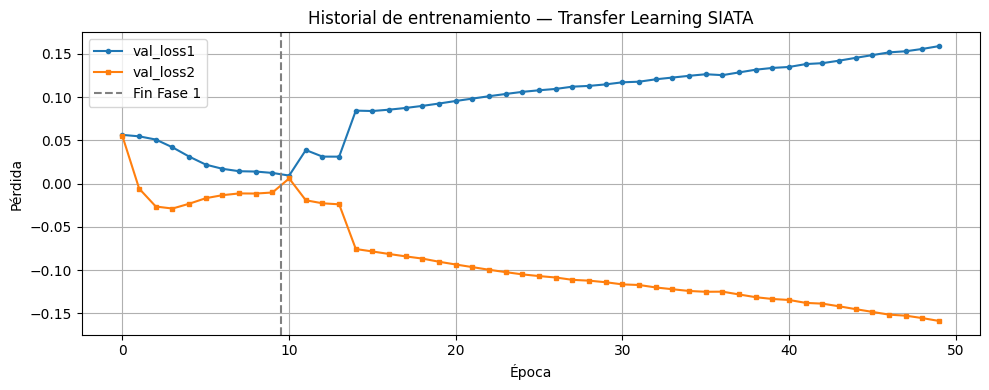

In [13]:
# ── Historial de pérdidas ──────────────────────────────────────────────────────
trainer.plot_history()

## Curvas ROC — Entrenamiento y Validación

In [14]:
evaluator = Evaluator(tl.model, DEVICE, ALPHA, BETA)

print("Calculando scores...")
train_scores = evaluator.compute_scores(data_loader.train_loader)
val_scores   = evaluator.compute_scores(data_loader.val_loader)
test_scores  = evaluator.compute_scores(data_loader.test_loader)

train_labels = data_loader.labels["train"]
val_labels   = data_loader.labels["val"]
test_labels  = data_loader.labels["test"]

print(f"Scores  — train: {len(train_scores):,}  val: {len(val_scores):,}  test: {len(test_scores):,}")

Calculando scores...
Scores  — train: 35,947  val: 5,736  test: 36,665


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


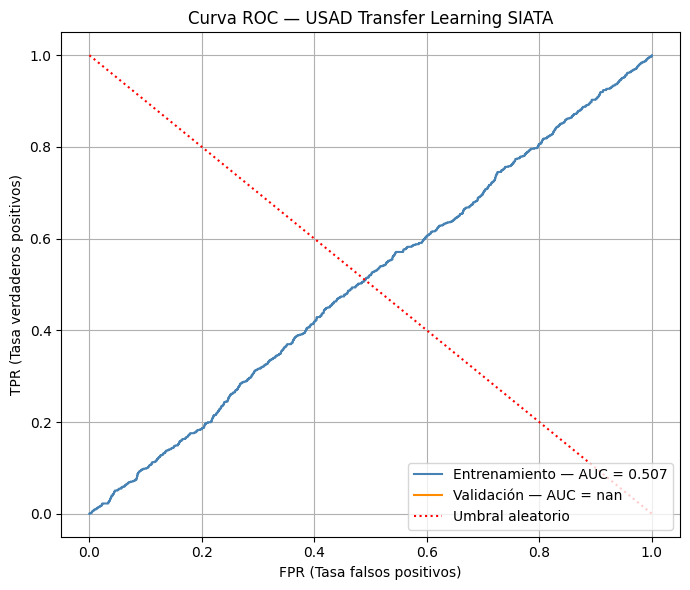

In [15]:
# Curva ROC con train y validación
evaluator.roc_curve_plot(
    train_scores, train_labels,
    val_scores,   val_labels
)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


Umbral óptimo (desde validación): inf


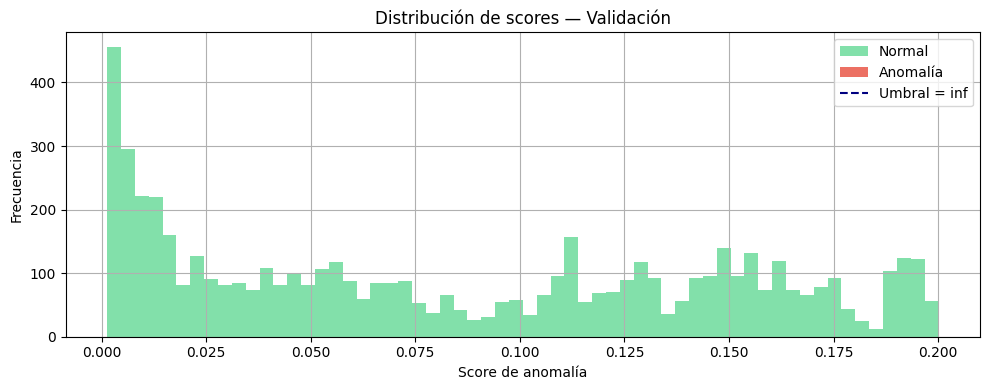

In [16]:
# Umbral óptimo desde validación (más conservador que train)
threshold = evaluator.find_threshold(val_scores, val_labels)
print(f"Umbral óptimo (desde validación): {threshold:.6f}")

evaluator.score_histogram(
    val_scores, val_labels, threshold,
    title="Distribución de scores — Validación"
)

## Métricas finales — Conjunto Test

=== Reporte sobre conjunto TEST ===
────────────────────────────────────────
  Umbral usado : inf
  Accuracy     : 0.7680
  F1-score     : 0.0000
  Precision    : 0.0000
  Recall       : 0.0000
────────────────────────────────────────


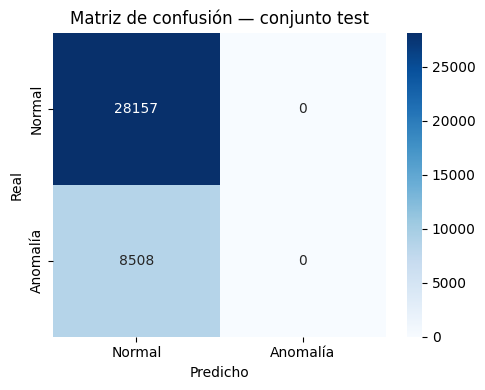

In [17]:
print("=== Reporte sobre conjunto TEST ===")
metrics = evaluator.classification_report(test_scores, test_labels, threshold)

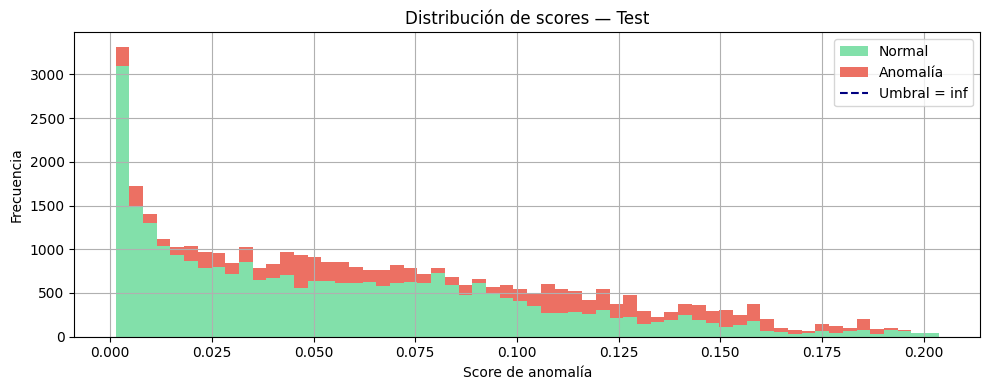

In [18]:
evaluator.score_histogram(
    test_scores, test_labels, threshold,
    title="Distribución de scores — Test"
)

## Detección de Anomalías — Test con validación de datos

=== Test sobre conjunto VALIDACIÓN ===
────────────────────────────────────────
  Umbral usado : inf
  Accuracy     : 1.0000
  F1-score     : 0.0000
  Precision    : 0.0000
  Recall       : 0.0000
────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


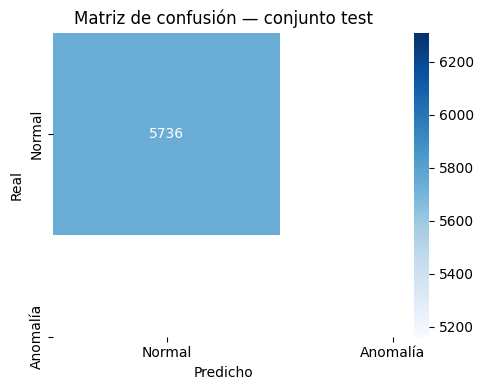

{'accuracy': 1.0, 'f1': 0.0, 'precision': 0.0, 'recall': 0.0}

In [19]:
# Test con datos de validación
print("=== Test sobre conjunto VALIDACIÓN ===")
evaluator.classification_report(val_scores, val_labels, threshold)

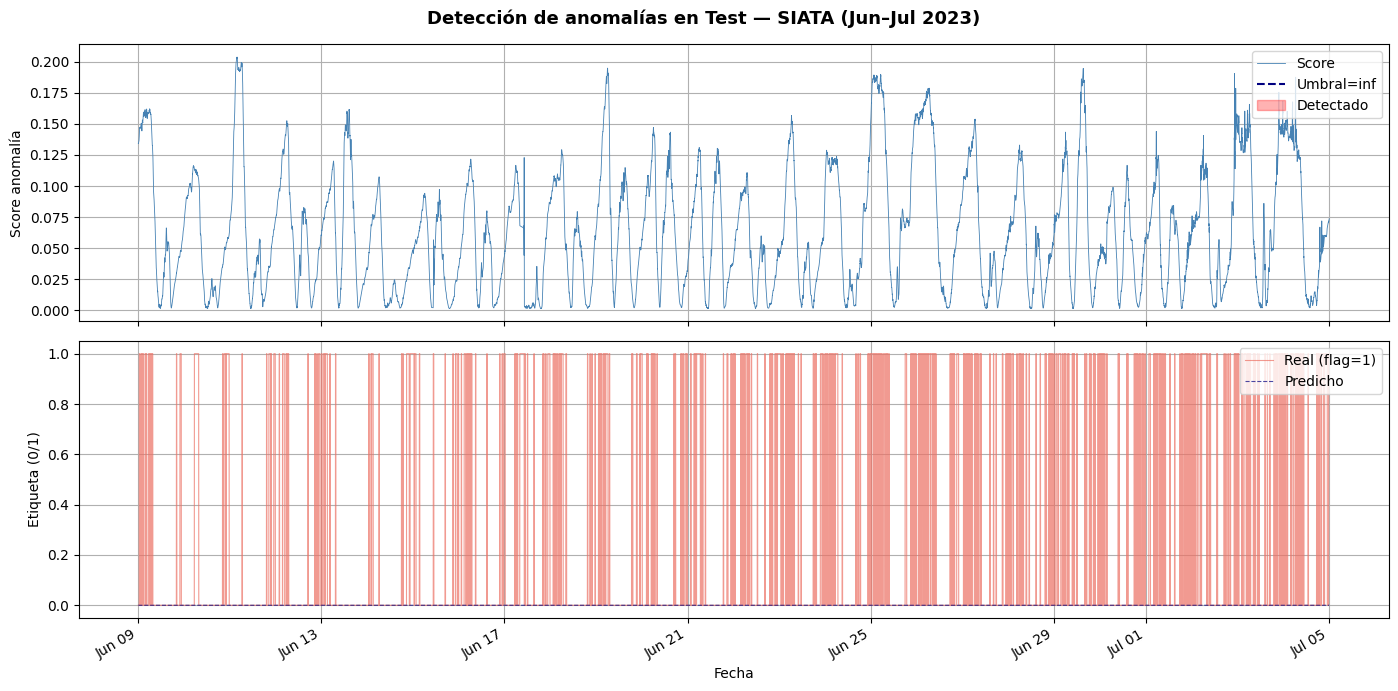

In [20]:
# Visualización temporal de anomalías detectadas en test
evaluator.plot_anomalies(
    timestamps = data_loader.timestamps["test"],
    scores     = test_scores,
    labels     = test_labels,
    threshold  = threshold,
    title      = "Detección de anomalías en Test — SIATA (Jun–Jul 2023)"
)

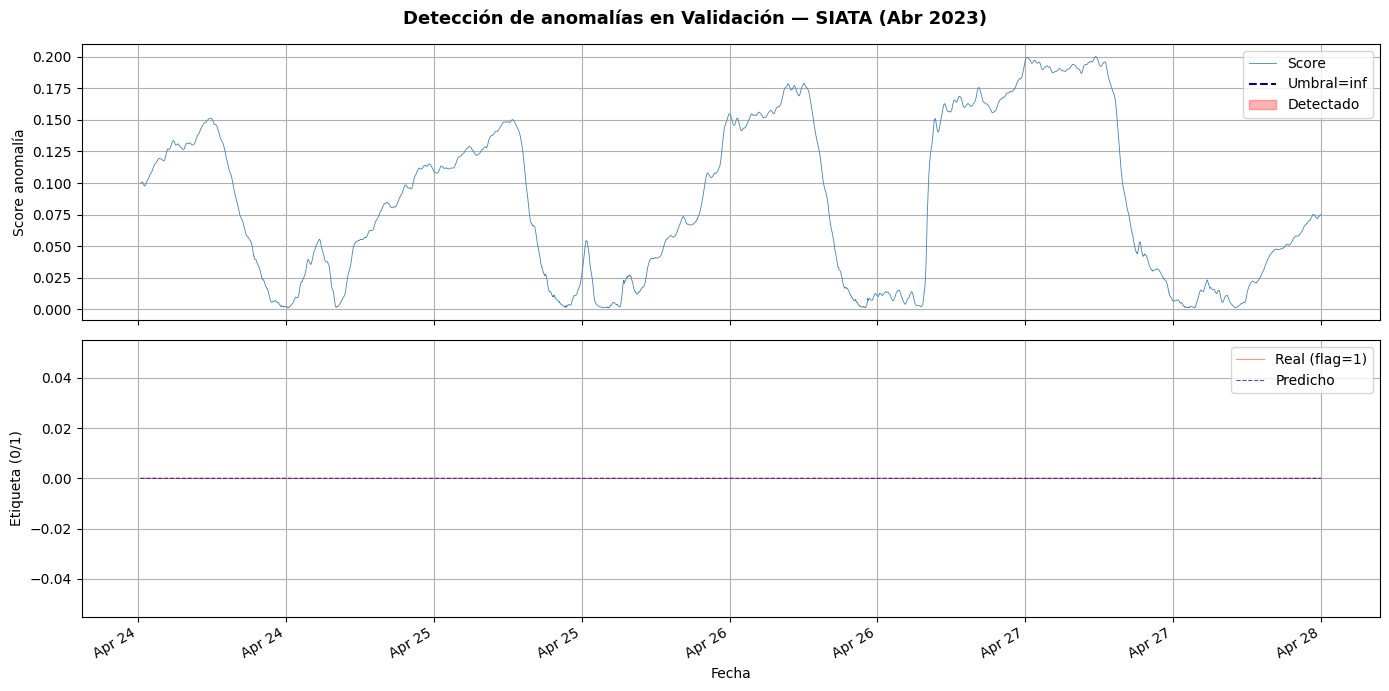

In [21]:
# Visualización temporal de anomalías en validación
evaluator.plot_anomalies(
    timestamps = data_loader.timestamps["val"],
    scores     = val_scores,
    labels     = val_labels,
    threshold  = threshold,
    title      = "Detección de anomalías en Validación — SIATA (Abr 2023)"
)

## Conclusiones

In [22]:
from sklearn.metrics import roc_auc_score

train_auc = roc_auc_score(train_labels, train_scores)
val_auc   = roc_auc_score(val_labels,   val_scores)
test_auc  = roc_auc_score(test_labels,  test_scores)

print("\n" + "═" * 55)
print("  CONCLUSIONES DEL TRANSFER LEARNING USAD → SIATA")
print("═" * 55)
print(f"\n  Modelo original: SWaT — 51 sensores, w_size=612")
print(f"  Modelo adaptado: SIATA — 4 sensores, w_size={W_SIZE_NEW}")
print(f"  Estrategia     : sub-matriz de pesos del encoder")
print(f"  Fine-tuning    : {EPOCHS_P1} épocas (enc congelado) + {EPOCHS_P2} (completo)")
print()
print(f"  AUC ROC — Entrenamiento : {train_auc:.4f}")
print(f"  AUC ROC — Validación    : {val_auc:.4f}")
print(f"  AUC ROC — Test          : {test_auc:.4f}")
print()
print(f"  F1-score (test) : {metrics['f1']:.4f}")
print(f"  Accuracy (test) : {metrics['accuracy']:.4f}")
print(f"  Precision       : {metrics['precision']:.4f}")
print(f"  Recall          : {metrics['recall']:.4f}")
print()

detectable = test_auc > 0.6 and metrics['f1'] > 0.4
print("  ¿Puede detectar anomalías? ", "SÍ ✓" if detectable else "LIMITADO ✗")

print()
print("  Notas sobre los sensores:")
print("  · 478 (Fiscalía)    — sin anomalías en datos, sirve de referencia")
print("  · 201 (Torre SIATA) — menor tasa de anomalías (1.16%), alta calidad")
print("  · 203 (UNAL)        — 118 horas incompletas + outlier 8.5°C (sensor 203)")
print("  · 68  (Jardín Bot.) — mayor tasa de anomalías (2.14%), más ruido")
print("═" * 55)


═══════════════════════════════════════════════════════
  CONCLUSIONES DEL TRANSFER LEARNING USAD → SIATA
═══════════════════════════════════════════════════════

  Modelo original: SWaT — 51 sensores, w_size=612
  Modelo adaptado: SIATA — 4 sensores, w_size=48
  Estrategia     : sub-matriz de pesos del encoder
  Fine-tuning    : 10 épocas (enc congelado) + 40 (completo)

  AUC ROC — Entrenamiento : 0.5068
  AUC ROC — Validación    : nan
  AUC ROC — Test          : 0.6821

  F1-score (test) : 0.0000
  Accuracy (test) : 0.7680
  Precision       : 0.0000
  Recall          : 0.0000

  ¿Puede detectar anomalías?  LIMITADO ✗

  Notas sobre los sensores:
  · 478 (Fiscalía)    — sin anomalías en datos, sirve de referencia
  · 201 (Torre SIATA) — menor tasa de anomalías (1.16%), alta calidad
  · 203 (UNAL)        — 118 horas incompletas + outlier 8.5°C (sensor 203)
  · 68  (Jardín Bot.) — mayor tasa de anomalías (2.14%), más ruido
═══════════════════════════════════════════════════════


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
